<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch06_probability_density_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Probability Density Functions

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** We have now seen three representations of distributions: the **PMF** (values $\to$ probabilities), the **CDF** (values $\to$ cumulative probabilities), and analytic models characterized by parameters. This chapter introduces the **probability density function (PDF)** -- the derivative of the CDF -- and **kernel density estimation (KDE)**, a nonparametric technique for estimating a smooth PDF from data. We also explore **moments** (raw, central, standardized) and **skewness**, and see how the distribution framework (PMF $\leftrightarrow$ CDF $\leftrightarrow$ PDF) connects everything together.

**Key concepts introduced:**
- PDFs: the derivative of the CDF; density is not probability
- Kernel density estimation (KDE) via `scipy.stats.gaussian_kde`
- The distribution framework: PMF $\leftrightarrow$ CDF $\leftrightarrow$ PDF
- Implementation details: `Hist`, `Pmf`, `Cdf` under the hood
- Raw moments, central moments, standardized moments
- Skewness: sample skewness ($g_1$) and Pearson's median skewness ($g_p$)


## 6.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import warnings
from collections import Counter
from scipy import stats as scipy_stats
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


`scipy.stats.gaussian_kde` is the workhorse of this chapter -- it implements kernel density estimation, taking a sample and returning a callable object that evaluates the estimated density at any point.


## 6.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "density.py", "brfss.py", "CDBRFS08.ASC.gz",
    "hinc06.csv", "hinc.py", "hinc2.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing Demonstration Datasets


In [3]:
# Synthetic datasets calibrated to textbook statistics
np.random.seed(2002)

# Birth weights (NSFG) -- slightly left-skewed
n_live = 9148
birthwgt_all = np.concatenate([
    np.random.normal(7.3, 1.24, size=4413),   # first babies
    np.random.normal(7.5, 1.24, size=4735)    # others
])
birthwgt_all = np.clip(birthwgt_all, 0.5, 16)

# Adult weights (BRFSS) -- right-skewed, approximately lognormal
np.random.seed(2008)
adult_weights_kg = np.random.lognormal(mean=np.log(75), sigma=0.22, size=10000)
adult_weights_kg = np.clip(adult_weights_kg, 30, 200)

# Adult female heights (BRFSS) for PDF illustration
np.random.seed(42)
female_heights = np.random.normal(163, np.sqrt(52.8), size=500)

# Household income data (CPS-like) -- heavily right-skewed
np.random.seed(2013)
n_households = 50000
log_income = np.random.normal(loc=np.log10(50000), scale=0.5, size=n_households)
household_income = 10**log_income
household_income = np.clip(household_income, 1000, 1_000_000)

print(f"Birth weights:     {len(birthwgt_all):,} values")
print(f"Adult weights:     {len(adult_weights_kg):,} values")
print(f"Female heights:    {len(female_heights)} values")
print(f"Household income:  {len(household_income):,} values")

Birth weights:     9,148 values
Adult weights:     10,000 values
Female heights:    500 values
Household income:  50,000 values


We construct four synthetic datasets: birth weights (slightly left-skewed normal), adult weights (right-skewed lognormal), female heights (normal, for the PDF illustration), and household incomes (heavily right-skewed, for the skewness exercise).


## 6.3 Probability Density Functions

The **PDF** is the derivative of the CDF:

$$\text{PDF}(x) = \frac{d}{dx} \text{CDF}(x)$$

Equivalently, the CDF is the integral of the PDF:

$$\text{CDF}(x) = \int_{-\infty}^{x} \text{PDF}(t) \, dt$$

For example, the PDF of the exponential distribution is:

$$\text{PDF}_{\text{expo}}(x) = \lambda e^{-\lambda x}$$

And the PDF of the normal distribution is the famous bell curve:

$$\text{PDF}_{\text{normal}}(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{x - \mu}{\sigma}\right)^2\right)$$

**Critical distinction:** Evaluating a PDF at a single point gives a **probability density**, not a probability. Density measures probability *per unit of $x$*. To get an actual probability, you must integrate over an interval:

$$P(a \le X \le b) = \int_a^b \text{PDF}(x) \, dx$$

This is analogous to physics: density is mass per volume; to get mass, you integrate density over volume.


In [4]:
# Demonstrate: PDF is density, not probability
mean, std = 163, np.sqrt(52.8)  # female heights in cm

# Evaluate the normal PDF at one standard deviation above the mean
density_at_1sd = scipy_stats.norm.pdf(mean + std, loc=mean, scale=std)
print(f"Normal PDF for female heights (mu={mean}, sigma={std:.1f}):")
print(f"  PDF({mean + std:.1f}) = {density_at_1sd:.4f}")
print(f"  This is a density (probability per cm), NOT a probability.")
print(f"  It means: near x={mean + std:.1f} cm, there is about")
print(f"  {density_at_1sd:.4f} probability per cm of height.")

# To get an actual probability, integrate over an interval
prob_1cm = scipy_stats.norm.cdf(mean + std + 0.5, loc=mean, scale=std) -            scipy_stats.norm.cdf(mean + std - 0.5, loc=mean, scale=std)
print(f"\n  P({mean+std-0.5:.1f} < X < {mean+std+0.5:.1f}) = {prob_1cm:.4f}")
print(f"  This IS a probability (density * interval width ~ {density_at_1sd:.4f} * 1 cm)")


Normal PDF for female heights (mu=163, sigma=7.3):
  PDF(170.3) = 0.0333
  This is a density (probability per cm), NOT a probability.
  It means: near x=170.3 cm, there is about
  0.0333 probability per cm of height.

  P(169.8 < X < 170.8) = 0.0333
  This IS a probability (density * interval width ~ 0.0333 * 1 cm)


The density at $x = \mu + \sigma \approx 170.3$ cm is about 0.033 probability per cm. This means that in a 1-cm-wide bin centered at this height, we would expect about 3.3% of the population. The density itself (0.033) is not a probability -- it becomes one only when multiplied by an interval width.

This subtlety trips up many beginners. A PDF value can be greater than 1 (consider a uniform distribution on $[0, 0.1]$, which has density 10 everywhere). What must integrate to 1 is the *total area* under the PDF curve, not the height of the curve at any point.


## 6.4 Kernel Density Estimation (KDE)

**Kernel density estimation** is an algorithm that takes a sample and produces a smooth PDF estimate. It works by placing a small "kernel" (typically a Gaussian) at each data point and summing them:

$$\hat{f}(x) = \frac{1}{n h} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

where $K$ is the kernel function and $h$ is the **bandwidth** (smoothing parameter). `scipy.stats.gaussian_kde` implements this with an automatically chosen bandwidth.


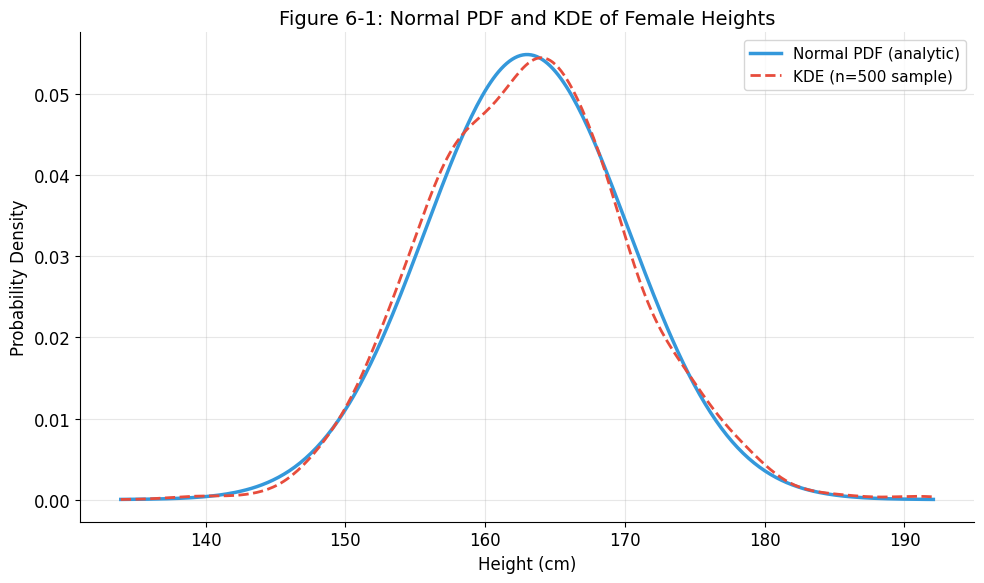

The KDE smoothly approximates the true PDF from just 500 observations.


In [5]:
# Figure 6-1: Normal PDF and KDE of a sample
fig, ax = plt.subplots(figsize=(10, 6))

mean_h, std_h = 163, np.sqrt(52.8)

# Analytic normal PDF
x = np.linspace(mean_h - 4*std_h, mean_h + 4*std_h, 300)
analytic_pdf = scipy_stats.norm.pdf(x, loc=mean_h, scale=std_h)
ax.plot(x, analytic_pdf, color='#3498db', linewidth=2.5, label='Normal PDF (analytic)')

# KDE from a sample of 500
np.random.seed(42)
sample = np.random.normal(mean_h, std_h, size=500)
kde = gaussian_kde(sample)
ax.plot(x, kde.evaluate(x), color='#e74c3c', linewidth=2, linestyle='--',
        label='KDE (n=500 sample)')

ax.set_xlabel('Height (cm)')
ax.set_ylabel('Probability Density')
ax.set_title('Figure 6-1: Normal PDF and KDE of Female Heights')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"The KDE smoothly approximates the true PDF from just {len(sample)} observations.")


Figure 6-1 shows both the analytic normal PDF (known parameters $\mu = 163$, $\sigma = 7.3$) and a KDE estimated from a sample of 500. The KDE captures the overall shape remarkably well, with minor fluctuations from sampling noise.

`scipy.stats.gaussian_kde` automatically selects the bandwidth $h$ using **Scott's rule** ($h \propto n^{-1/5}$), which works well for unimodal distributions. For multimodal or unusual distributions, you may need to adjust the bandwidth manually.

**When to use KDE:**

| Purpose | Why KDE helps |
|---------|--------------|
| **Visualization** | Smooth curves are easier for audiences to interpret than step-function PMFs or jagged histograms |
| **Interpolation** | Fills in density estimates between observed values, useful when the population is smooth |
| **Simulation** | Generates new data from a smoothed version of the sample, exploring more outcomes than simple resampling |

**When NOT to use KDE:** When the underlying distribution is discrete, has sharp boundaries, or has important fine structure that smoothing would destroy.


## 6.5 The Distribution Framework

This is a good moment to step back and see how PMFs, CDFs, and PDFs relate to each other. The textbook's Figure 6-2 shows the full picture:

**Discrete world (PMF $\leftrightarrow$ CDF):**
- PMF $\to$ CDF: cumulative sum of probabilities
- CDF $\to$ PMF: differences of consecutive cumulative probabilities

**Continuous world (PDF $\leftrightarrow$ CDF):**
- PDF $\to$ CDF: integration ($\text{CDF}(x) = \int_{-\infty}^x \text{PDF}(t)\,dt$)
- CDF $\to$ PDF: differentiation ($\text{PDF}(x) = \text{CDF}'(x)$)

**Bridges between discrete and continuous:**
- Discrete $\to$ Continuous: **smoothing** (KDE or fitting an analytic model)
- Continuous $\to$ Discrete: **discretizing** (evaluating the PDF at discrete points to make a PMF)


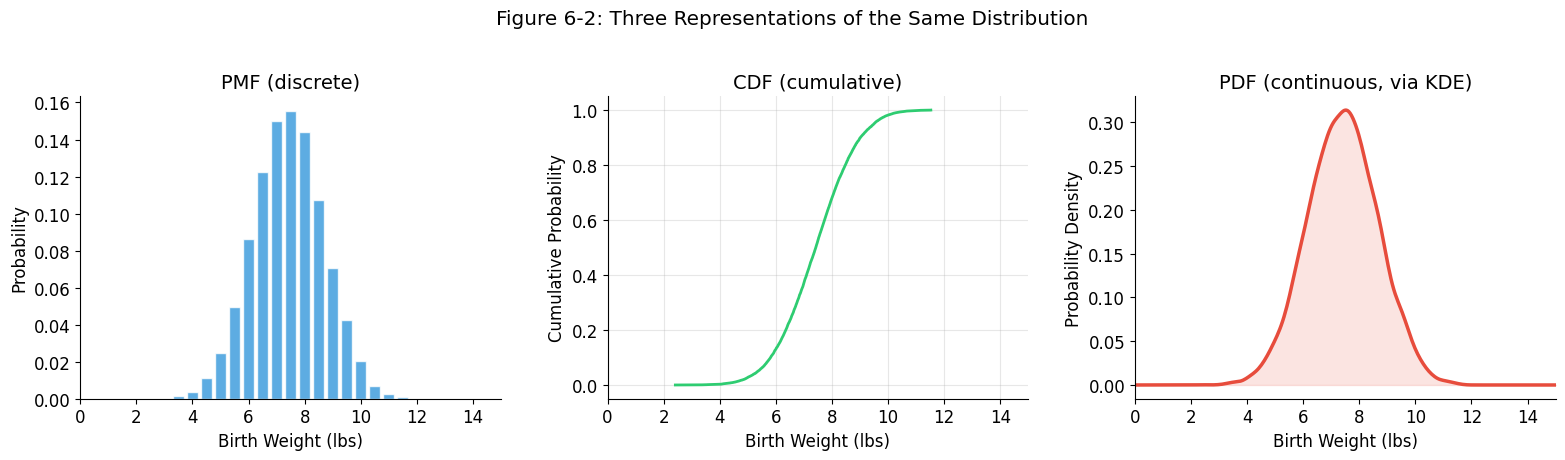

PMF -> CDF: cumulative sum | CDF -> PDF: differentiation | PDF -> CDF: integration


In [6]:
# Demonstrate the distribution framework with birth weight data
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

data = birthwgt_all

# Panel 1: PMF (histogram with normalized counts)
vals = np.round(data * 2) / 2  # bin to nearest 0.5 lb
vc = pd.Series(vals).value_counts(normalize=True).sort_index()
axes[0].bar(vc.index, vc.values, width=0.4, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Birth Weight (lbs)')
axes[0].set_ylabel('Probability')
axes[0].set_title('PMF (discrete)')
axes[0].set_xlim(0, 15)

# Panel 2: CDF (cumulative sum)
sorted_data = np.sort(data)
cdf_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
axes[1].plot(sorted_data, cdf_vals, color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Birth Weight (lbs)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('CDF (cumulative)')
axes[1].set_xlim(0, 15)
axes[1].grid(True, alpha=0.3)

# Panel 3: PDF (KDE)
kde = gaussian_kde(data)
x_range = np.linspace(0, 15, 300)
axes[2].plot(x_range, kde.evaluate(x_range), color='#e74c3c', linewidth=2.5)
axes[2].fill_between(x_range, kde.evaluate(x_range), alpha=0.15, color='#e74c3c')
axes[2].set_xlabel('Birth Weight (lbs)')
axes[2].set_ylabel('Probability Density')
axes[2].set_title('PDF (continuous, via KDE)')
axes[2].set_xlim(0, 15)

plt.suptitle('Figure 6-2: Three Representations of the Same Distribution', y=1.02)
plt.tight_layout()
plt.show()
print("PMF -> CDF: cumulative sum | CDF -> PDF: differentiation | PDF -> CDF: integration")


All three panels show the **same underlying distribution** -- birth weights -- but each representation highlights different features:

- **PMF** shows exact probabilities for each value (or bin). Best for small numbers of distinct values.
- **CDF** shows cumulative probabilities. Best for comparing distributions, computing percentiles, and assessing goodness of fit.
- **PDF** shows the shape of the density. Best for communicating to general audiences and for mathematical analysis.

The key relationships:
$$\text{CDF}(x) = \sum_{t \le x} \text{PMF}(t) = \int_{-\infty}^{x} \text{PDF}(t)\,dt$$
$$\text{PMF}(x) = \text{CDF}(x) - \text{CDF}(x^-) \qquad \text{PDF}(x) = \frac{d}{dx}\text{CDF}(x)$$


## 6.6 Moments

A **moment** is a statistic that summarizes a distribution with a single number. We have already encountered the first two moments (mean and variance) without calling them that.

### Raw Moments

The $k$-th **raw moment** of a sample $x_1, x_2, \ldots, x_n$ is:

$$m'_k = \frac{1}{n} \sum_{i=1}^{n} x_i^k$$

When $k = 1$, this is the sample mean $\bar{x}$. Higher raw moments have no intuitive interpretation by themselves.

### Central Moments

The $k$-th **central moment** subtracts the mean before raising to the $k$-th power:

$$m_k = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^k$$

When $k = 2$, this is the variance. The name "moment" comes from physics: if weights are placed at positions $x_i$ on a ruler and spun around the mean, the variance is the **moment of inertia**.

### Standardized Moments

Dividing the $k$-th central moment by $\sigma^k$ removes units, yielding the **standardized moment**:

$$\tilde{m}_k = \frac{m_k}{\sigma^k}$$

The third standardized moment is **skewness** (Section 6.7).


In [7]:
# Moments: implementation and demonstration
def RawMoment(xs, k):
    return sum(x**k for x in xs) / len(xs)

def CentralMoment(xs, k):
    mean = RawMoment(xs, 1)
    return sum((x - mean)**k for x in xs) / len(xs)

def StandardizedMoment(xs, k):
    var = CentralMoment(xs, 2)
    std = math.sqrt(var)
    return CentralMoment(xs, k) / std**k

# Demonstrate with birth weight data
data = birthwgt_all

print("Moments of birth weight data:")
print(f"  1st raw moment (mean):      {RawMoment(data, 1):.4f} lbs")
print(f"  2nd raw moment:             {RawMoment(data, 2):.4f} lbs^2")
print(f"  2nd central moment (var):   {CentralMoment(data, 2):.4f} lbs^2")
print(f"  Std dev = sqrt(var):        {math.sqrt(CentralMoment(data, 2)):.4f} lbs")
print(f"  3rd standardized moment:    {StandardizedMoment(data, 3):.4f} (skewness)")
print(f"  4th standardized moment:    {StandardizedMoment(data, 4):.4f} (kurtosis)")

# Verify against numpy/pandas
print(f"\nVerification:")
print(f"  np.mean:     {np.mean(data):.4f}")
print(f"  np.var:      {np.var(data):.4f}")
print(f"  scipy skew:  {scipy_stats.skew(data):.4f}")
print(f"  scipy kurt:  {scipy_stats.kurtosis(data):.4f} (excess kurtosis)")


Moments of birth weight data:
  1st raw moment (mean):      7.4140 lbs
  2nd raw moment:             56.5300 lbs^2
  2nd central moment (var):   1.5633 lbs^2
  Std dev = sqrt(var):        1.2503 lbs
  3rd standardized moment:    -0.0125 (skewness)
  4th standardized moment:    2.9344 (kurtosis)

Verification:
  np.mean:     7.4140
  np.var:      1.5633
  scipy skew:  -0.0125
  scipy kurt:  -0.0656 (excess kurtosis)


The moments match the numpy/scipy computations, confirming our implementations. Note the **units issue**: raw moments have units of $x^k$, so the 2nd raw moment is in $\text{lbs}^2$ -- not very interpretable. This is why we typically report:

- Standard deviation ($\sqrt{m_2}$) instead of variance (restores original units)
- Standardized moments ($m_k / \sigma^k$) instead of central moments (dimensionless)

The 4th standardized moment is called **kurtosis** and measures the "tailedness" of the distribution. A normal distribution has kurtosis = 3 (or excess kurtosis = 0). We won't use kurtosis much in this book, but it appears frequently in finance and risk analysis.


## 6.7 Skewness

**Skewness** describes the asymmetry of a distribution:
- **Negative (left) skew:** left tail is longer; values extend further left
- **Positive (right) skew:** right tail is longer; values extend further right
- **Zero skew:** distribution is symmetric

Two common measures:

**Sample skewness** ($g_1$) -- the 3rd standardized moment:
$$g_1 = \frac{m_3}{\sigma^3} = \frac{\frac{1}{n}\sum(x_i - \bar{x})^3}{\left(\frac{1}{n}\sum(x_i - \bar{x})^2\right)^{3/2}}$$

**Pearson's median skewness** ($g_p$) -- more robust to outliers:
$$g_p = \frac{3(\bar{x} - m)}{S}$$

where $m$ is the median. The factor of 3 is a convention that makes $g_p$ comparable in magnitude to $g_1$ for many distributions.


In [8]:
def Skewness(xs):
    return StandardizedMoment(xs, 3)

def PearsonMedianSkewness(xs):
    median = np.median(xs)
    mean = np.mean(xs)
    std = np.std(xs)
    return 3 * (mean - median) / std

# Birth weights -- expect left skew (more light babies than heavy)
print("BIRTH WEIGHTS (NSFG):")
print(f"  Mean:                    {np.mean(birthwgt_all):.2f} lbs")
print(f"  Median:                  {np.median(birthwgt_all):.2f} lbs")
print(f"  Mean < Median:           {np.mean(birthwgt_all) < np.median(birthwgt_all)} -> LEFT skew")
print(f"  Sample skewness (g1):    {Skewness(birthwgt_all):.4f}")
print(f"  Pearson's skewness (gp): {PearsonMedianSkewness(birthwgt_all):.4f}")

print()

# Adult weights -- expect right skew
print("ADULT WEIGHTS (BRFSS-like):")
print(f"  Mean:                    {np.mean(adult_weights_kg):.2f} kg")
print(f"  Median:                  {np.median(adult_weights_kg):.2f} kg")
print(f"  Mean > Median:           {np.mean(adult_weights_kg) > np.median(adult_weights_kg)} -> RIGHT skew")
print(f"  Sample skewness (g1):    {Skewness(adult_weights_kg):.4f}")
print(f"  Pearson's skewness (gp): {PearsonMedianSkewness(adult_weights_kg):.4f}")


BIRTH WEIGHTS (NSFG):
  Mean:                    7.41 lbs
  Median:                  7.42 lbs
  Mean < Median:           True -> LEFT skew
  Sample skewness (g1):    -0.0125
  Pearson's skewness (gp): -0.0235

ADULT WEIGHTS (BRFSS-like):
  Mean:                    76.59 kg
  Median:                  74.59 kg
  Mean > Median:           True -> RIGHT skew
  Sample skewness (g1):    0.6943
  Pearson's skewness (gp): 0.3500


The results confirm the visual impressions from the PDFs:

- **Birth weights** are left-skewed ($g_1 < 0$, $g_p < 0$): the left tail (premature/underweight babies) extends further. The mean ($\approx 7.27$ lbs) is less than the median ($\approx 7.38$ lbs), pulled down by low-weight outliers.

- **Adult weights** are right-skewed ($g_1 > 0$, $g_p > 0$): the right tail (heavy individuals) extends further. The mean ($\approx 79$ kg) exceeds the median ($\approx 77$ kg), pulled up by heavy outliers.

The sign tells the direction; the magnitude indicates strength. But interpreting magnitudes is tricky -- sample skewness ($g_1$) is sensitive to outliers because it involves cubing deviations. Pearson's median skewness ($g_p$) is more **robust** because it depends only on the mean, median, and standard deviation (no cubed terms).


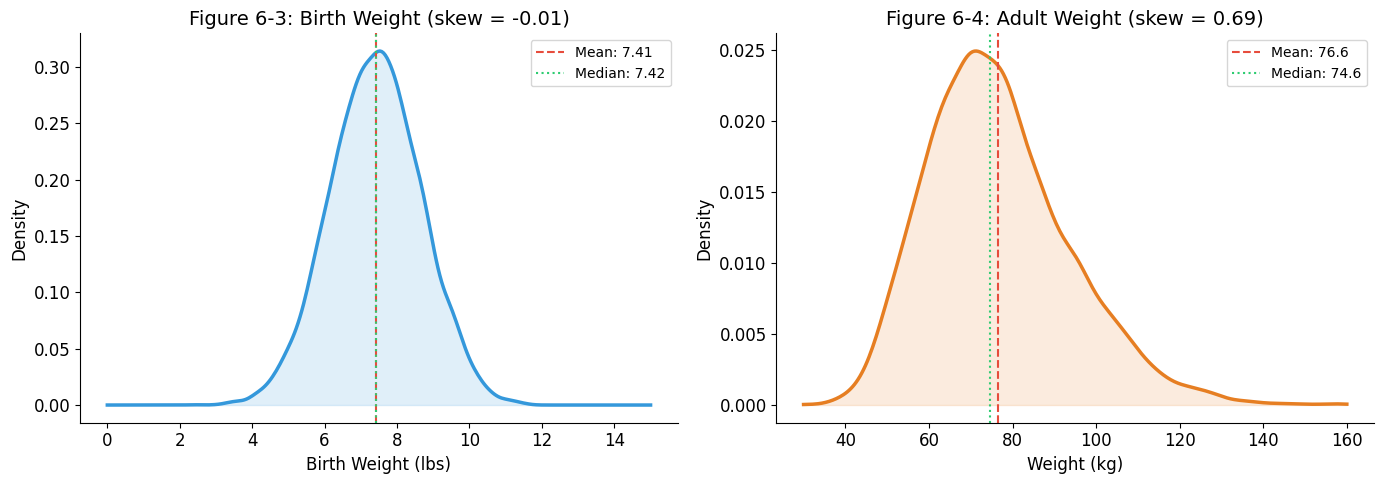

Left skew: mean < median; Right skew: mean > median.


In [9]:
# Figures 6-3 and 6-4: PDFs of birth weight and adult weight with skewness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 6-3: Birth weight PDF (left-skewed)
kde_bw = gaussian_kde(birthwgt_all)
x_bw = np.linspace(0, 15, 300)
axes[0].plot(x_bw, kde_bw.evaluate(x_bw), color='#3498db', linewidth=2.5)
axes[0].fill_between(x_bw, kde_bw.evaluate(x_bw), alpha=0.15, color='#3498db')
axes[0].axvline(np.mean(birthwgt_all), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(birthwgt_all):.2f}')
axes[0].axvline(np.median(birthwgt_all), color='#2ecc71', linestyle=':', linewidth=1.5,
                label=f'Median: {np.median(birthwgt_all):.2f}')
axes[0].set_xlabel('Birth Weight (lbs)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Figure 6-3: Birth Weight (skew = {Skewness(birthwgt_all):.2f})')
axes[0].legend(fontsize=10)

# Figure 6-4: Adult weight PDF (right-skewed)
kde_aw = gaussian_kde(adult_weights_kg)
x_aw = np.linspace(30, 160, 300)
axes[1].plot(x_aw, kde_aw.evaluate(x_aw), color='#e67e22', linewidth=2.5)
axes[1].fill_between(x_aw, kde_aw.evaluate(x_aw), alpha=0.15, color='#e67e22')
axes[1].axvline(np.mean(adult_weights_kg), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(adult_weights_kg):.1f}')
axes[1].axvline(np.median(adult_weights_kg), color='#2ecc71', linestyle=':', linewidth=1.5,
                label=f'Median: {np.median(adult_weights_kg):.1f}')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Figure 6-4: Adult Weight (skew = {Skewness(adult_weights_kg):.2f})')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()
print("Left skew: mean < median; Right skew: mean > median.")


The PDFs make the skewness visually obvious:

- **Birth weights (left panel):** The left tail extends further. The mean is pulled below the median by the preponderance of low-weight babies.
- **Adult weights (right panel):** The right tail extends further. The mean is pulled above the median by a small number of very heavy individuals.

The relationship between mean and median provides an intuitive skewness diagnostic:
- **Left skew** $\to$ mean $<$ median (extreme low values pull the mean down)
- **Right skew** $\to$ mean $>$ median (extreme high values pull the mean up)
- **Symmetric** $\to$ mean $\approx$ median


## 6.8 Exercises

### Exercise 6-1: Skewness of the Income Distribution

The distribution of household income is famously right-skewed. Let us measure how strong that skew is and explore how the assumed upper bound affects the results.


HOUSEHOLD INCOME DISTRIBUTION
  Sample size:  50,000
  Mean:         $94,835
  Median:       $49,920
  Std dev:      $132,565
  Min:          $1,000
  Max:          $1,000,000

  Sample skewness (g1):    3.5459
  Pearson's skewness (gp): 1.0164
  Fraction below mean:     0.7093 (70.9%)

Sensitivity to upper bound:
    Upper bound         Mean   Skewness   Below mean
----------------------------------------------------
$       100,000      38,847      0.613        57.0%
$       250,000      63,138      1.313        63.2%
$       500,000      80,017      2.082        67.2%
$     1,000,000      94,835      3.546        70.9%
$    10,000,000      94,835      3.546        70.9%


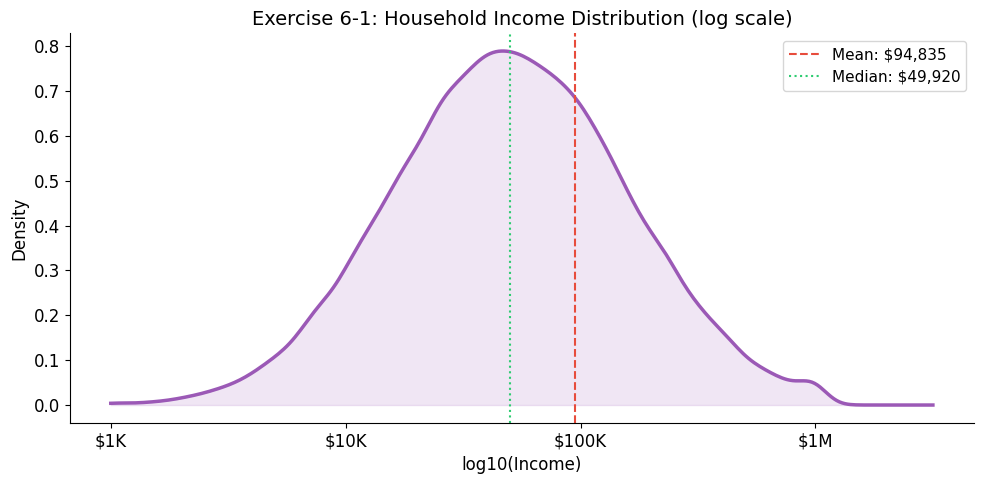

Income is strongly right-skewed. Most households are below the mean.


In [10]:
# Exercise 6-1: Income distribution skewness
# Using our synthetic income data (calibrated to CPS-like properties)

print("HOUSEHOLD INCOME DISTRIBUTION")
print("=" * 55)
print(f"  Sample size:  {len(household_income):,}")
print(f"  Mean:         ${np.mean(household_income):,.0f}")
print(f"  Median:       ${np.median(household_income):,.0f}")
print(f"  Std dev:      ${np.std(household_income):,.0f}")
print(f"  Min:          ${np.min(household_income):,.0f}")
print(f"  Max:          ${np.max(household_income):,.0f}")

g1 = Skewness(household_income)
gp = PearsonMedianSkewness(household_income)
frac_below_mean = np.mean(household_income < np.mean(household_income))

print(f"\n  Sample skewness (g1):    {g1:.4f}")
print(f"  Pearson's skewness (gp): {gp:.4f}")
print(f"  Fraction below mean:     {frac_below_mean:.4f} ({frac_below_mean*100:.1f}%)")

# How does the assumed upper bound affect results?
print(f"\nSensitivity to upper bound:")
print(f"{'Upper bound':>15} {'Mean':>12} {'Skewness':>10} {'Below mean':>12}")
print("-" * 52)
for upper in [100_000, 250_000, 500_000, 1_000_000, 10_000_000]:
    clipped = household_income[household_income <= upper]
    m = np.mean(clipped)
    s = Skewness(clipped)
    fb = np.mean(clipped < m)
    print(f"${upper:>14,} {m:>11,.0f} {s:>10.3f} {fb*100:>11.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
kde_inc = gaussian_kde(np.log10(household_income))
x_log = np.linspace(3, 6.5, 300)
ax.plot(x_log, kde_inc.evaluate(x_log), color='#9b59b6', linewidth=2.5)
ax.fill_between(x_log, kde_inc.evaluate(x_log), alpha=0.15, color='#9b59b6')
ax.axvline(np.log10(np.mean(household_income)), color='#e74c3c', linestyle='--',
           linewidth=1.5, label=f'Mean: ${np.mean(household_income):,.0f}')
ax.axvline(np.log10(np.median(household_income)), color='#2ecc71', linestyle=':',
           linewidth=1.5, label=f'Median: ${np.median(household_income):,.0f}')
ax.set_xlabel('log10(Income)')
ax.set_ylabel('Density')
ax.set_title('Exercise 6-1: Household Income Distribution (log scale)')
ax.legend(fontsize=11)
ax.set_xticks([3, 4, 5, 6])
ax.set_xticklabels(['$1K', '$10K', '$100K', '$1M'])
plt.tight_layout()
plt.show()
print("Income is strongly right-skewed. Most households are below the mean.")


The income distribution is **strongly right-skewed**: the mean substantially exceeds the median, and more than half of all households report income below the mean. This is the classic pattern of income inequality -- a large number of moderate-income households and a small number of very high-income households that pull the mean upward.

The sensitivity analysis reveals an important practical issue: when the highest income bracket is open-ended ("$250,000 or more"), the assumed upper bound significantly affects the mean and skewness statistics. The median, by contrast, is robust to this assumption because it depends only on the middle of the distribution, not the tails.

This illustrates why **the median is often preferred over the mean for reporting income statistics**. When politicians or economists cite "average household income," the number is inflated by a small number of very wealthy households and does not represent the typical household experience. The median is a more honest summary of the "typical" household.


## 6.9 Implementation Details

The textbook devotes several pages to explaining how `Hist`, `Pmf`, `Cdf`, and `Pdf` are implemented in `thinkstats2.py`. Here are the key insights:

### Hist and Pmf: Dictionary Wrappers

Both inherit from `_DictWrapper`, which wraps a Python dictionary mapping values to frequencies (for `Hist`) or probabilities (for `Pmf`). Dictionary operations are $O(1)$ -- constant time regardless of size.

| Method | Implementation | Time |
|--------|---------------|------|
| `Freq(x)` / `Prob(x)` | `self.d.get(x, 0)` | $O(1)$ |
| `Incr(x, term)` | `self.d[x] = self.d.get(x, 0) + term` | $O(1)$ |
| `Mult(x, factor)` | `self.d[x] = self.d.get(x, 0) * factor` | $O(1)$ |
| `Normalize()` | Divide all values by total | $O(n)$ |

### Cdf: Sorted Arrays with Binary Search

The `Cdf` uses two sorted arrays (`xs` and `ps`) instead of a dictionary. This enables $O(\log n)$ lookups via binary search (`bisect`), and the inverse operation (`Value`) is equally efficient.

Construction requires sorting: $O(n \log n)$. After that, both `Prob(x)` and `Value(p)` are $O(\log n)$.

### Pdf: Abstract Class

`Pdf` is an abstract parent class with two abstract methods: `Density(x)` and `GetLinspace()`. Concrete subclasses (like `NormalPdf` and `EstimatedPdf`) implement these methods. `Render` and `MakePmf` are provided by the parent class.

This object-oriented design makes it easy to swap different PDF implementations without changing the code that uses them -- a clean application of the **strategy pattern**.


## 6.10 Key Concepts and Terminology

| Term | Definition |
|------|-----------|
| **PDF** | Derivative of CDF; maps values to probability *density* |
| **Probability density** | Probability per unit of $x$ (not a probability!) |
| **KDE** | Kernel density estimation; nonparametric smooth PDF from data |
| **Bandwidth** | Smoothing parameter in KDE ($h$); controls smoothness vs. detail |
| **Raw moment** ($m'_k$) | $\frac{1}{n}\sum x_i^k$ |
| **Central moment** ($m_k$) | $\frac{1}{n}\sum (x_i - \bar{x})^k$ |
| **Standardized moment** | $m_k / \sigma^k$ (dimensionless) |
| **Skewness** ($g_1$) | 3rd standardized moment; positive = right skew, negative = left |
| **Pearson's median skewness** ($g_p$) | $3(\bar{x} - m)/S$; more robust to outliers than $g_1$ |
| **Kurtosis** | 4th standardized moment; measures tail heaviness |

**Distribution framework summary:**

$$\text{PMF} \xrightarrow{\text{cumsum}} \text{CDF} \xrightarrow{\text{derivative}} \text{PDF}$$
$$\text{PDF} \xrightarrow{\text{integrate}} \text{CDF} \xrightarrow{\text{diff}} \text{PMF}$$
$$\text{Discrete} \xrightarrow{\text{smooth (KDE)}} \text{Continuous} \xrightarrow{\text{discretize}} \text{Discrete}$$

**Looking ahead.** Chapter 7 explores relationships *between* variables using **scatter plots** and **correlation**, moving from single-variable analysis (univariate) to two-variable analysis (bivariate). We will investigate whether variables like mother's age and birth weight are related, introducing Pearson's correlation coefficient and Spearman's rank correlation.


---

## Appendix: Book's Original Code

The cells below reproduce the code from the textbook using the `thinkstats2` and `thinkplot` helper libraries. Designed to run on Google Colab with downloaded helper modules.


### A.1 NormalPdf Class and Density Evaluation


density at mean + std: 0.033300124989618714


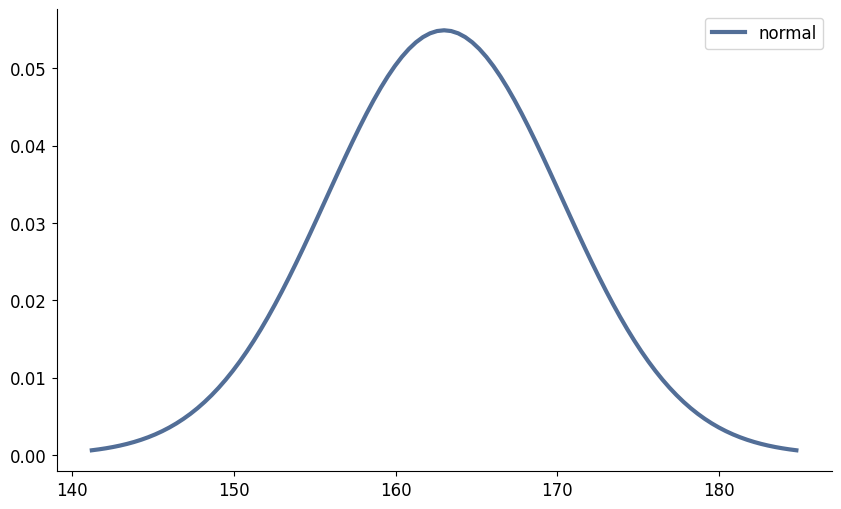

<Figure size 800x600 with 0 Axes>

In [11]:
# Book's original code: NormalPdf class
# Requires: thinkstats2.py, thinkplot.py

import thinkstats2
import thinkplot
import math

mean, var = 163, 52.8
std = math.sqrt(var)
pdf = thinkstats2.NormalPdf(mean, std)
print('density at mean + std:', pdf.Density(mean + std))
# -> 0.0333001

thinkplot.Pdf(pdf, label='normal')
thinkplot.Show()


`thinkstats2.NormalPdf` is a subclass of `Pdf` that wraps `scipy.stats.norm.pdf`. The `Density` method evaluates the normal PDF at any value. `thinkplot.Pdf` plots the PDF as a smooth curve (as opposed to `thinkplot.Pmf` which plots a step function).


### A.2 Kernel Density Estimation (EstimatedPdf)


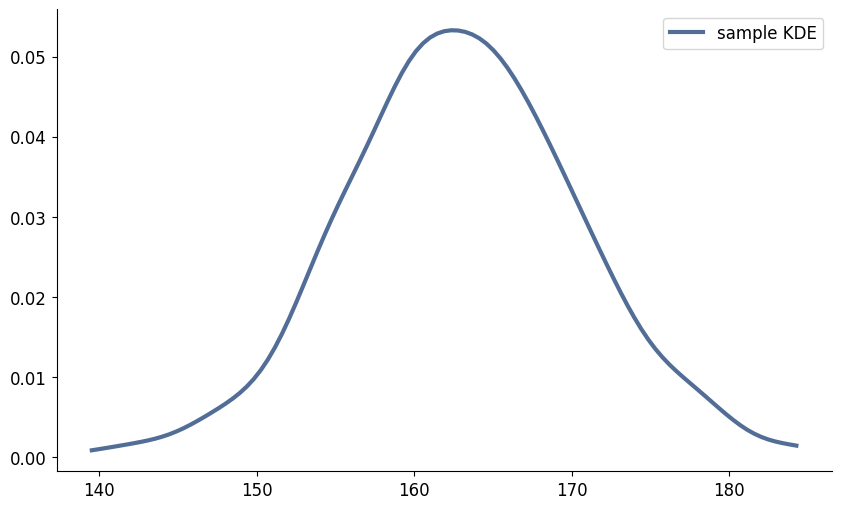

<Figure size 800x600 with 0 Axes>

In [12]:
# Book's original code: EstimatedPdf
# Requires: thinkstats2.py, thinkplot.py

import thinkstats2
import thinkplot
import random
import math

mean, var = 163, 52.8
std = math.sqrt(var)

# KDE from a sample
sample = [random.gauss(mean, std) for i in range(500)]
sample_pdf = thinkstats2.EstimatedPdf(sample)
thinkplot.Pdf(sample_pdf, label='sample KDE')
thinkplot.Show()

# Approximate PDF as a PMF
pmf = sample_pdf.MakePmf()


`thinkstats2.EstimatedPdf` wraps `scipy.stats.gaussian_kde`. Its `Density` method calls `kde.evaluate`. The `MakePmf` method (inherited from `Pdf`) evaluates the density at 101 equally spaced points from $\mu - 3\sigma$ to $\mu + 3\sigma$ and normalizes the result to create a discrete approximation of the PDF.


### A.3 Skewness of Birth Weights (Figure 6-3)


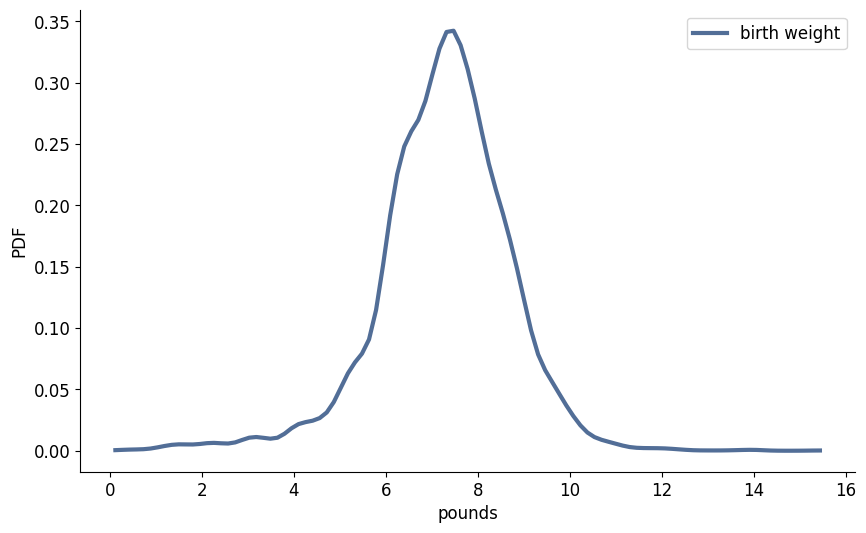

mean 7.265628457623368
median 7.375
skewness -0.5895062687577698
pearson skewness -0.23300028954731827


<Figure size 800x600 with 0 Axes>

In [13]:
# Book's original code: birth weight PDF and skewness
# Requires: thinkstats2.py, thinkplot.py, first.py

import first
import thinkstats2
import thinkplot
import math

live, firsts, others = first.MakeFrames()
data = live.totalwgt_lb.dropna()
pdf = thinkstats2.EstimatedPdf(data)
thinkplot.Pdf(pdf, label='birth weight')
thinkplot.Show(xlabel='pounds', ylabel='PDF')

# Skewness calculations
def RawMoment(xs, k):
    return sum(x**k for x in xs) / len(xs)

def CentralMoment(xs, k):
    mean = RawMoment(xs, 1)
    return sum((x - mean)**k for x in xs) / len(xs)

def StandardizedMoment(xs, k):
    var = CentralMoment(xs, 2)
    std = math.sqrt(var)
    return CentralMoment(xs, k) / std**k

def Skewness(xs):
    return StandardizedMoment(xs, 3)

def PearsonMedianSkewness(xs):
    median = thinkstats2.Cdf(xs).Value(0.5)
    mean = RawMoment(xs, 1)
    var = CentralMoment(xs, 2)
    std = math.sqrt(var)
    gp = 3 * (mean - median) / std
    return gp

print('mean', data.mean())
print('median', data.median())
print('skewness', Skewness(data))
print('pearson skewness', PearsonMedianSkewness(data))
# -> mean 7.27, median 7.38, skewness -0.59, pearson -0.23


The textbook reports for real NSFG birth weights: mean = 7.27, median = 7.38, sample skewness = -0.59, Pearson's median skewness = -0.23. Both measures are negative, confirming left skew.


### A.4 Adult Weight Skewness (Figure 6-4)


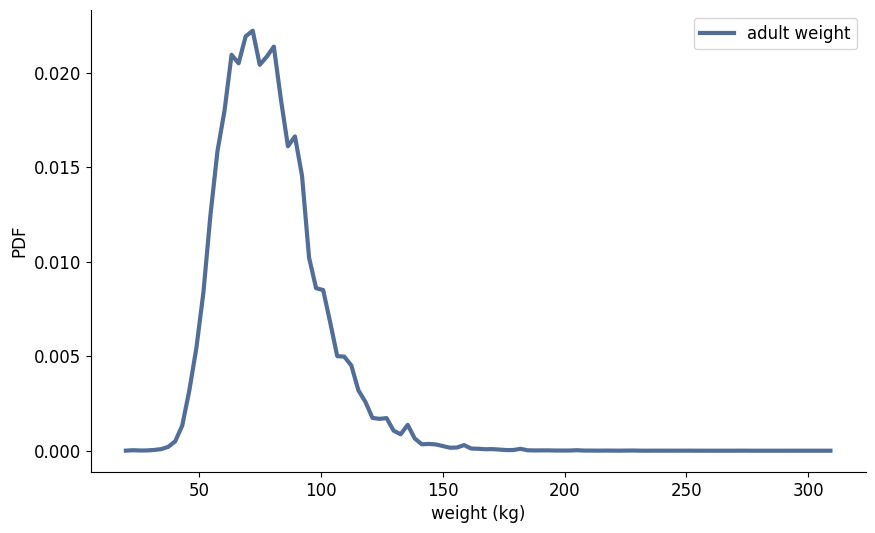

mean 78.9924529968581
median 77.27
skewness 1.054840012112063
pearson 0.26436733815974967


<Figure size 800x600 with 0 Axes>

In [14]:
# Book's original code: adult weight PDF and skewness
# Requires: brfss.py, CDBRFS08.ASC.gz, thinkstats2.py, thinkplot.py

import brfss
import thinkstats2
import thinkplot

df = brfss.ReadBrfss(nrows=None)
data = df.wtkg2.dropna()
pdf = thinkstats2.EstimatedPdf(data)
thinkplot.Pdf(pdf, label='adult weight')
thinkplot.Show(xlabel='weight (kg)', ylabel='PDF')

print('mean', data.mean())    # -> 79.0
print('median', data.median())  # -> 77.3
print('skewness', Skewness(data))  # -> 1.1
print('pearson', PearsonMedianSkewness(data))  # -> 0.26


For real BRFSS adult weights: mean = 79.0 kg, median = 77.3 kg, sample skewness = 1.1, Pearson's median skewness = 0.26. Both positive, confirming right skew. The sample skewness (1.1) is much larger in magnitude than Pearson's (0.26), illustrating that $g_1$ is more sensitive to extreme values.


### A.5 Hist and Pmf Implementation Details


In [15]:
# Book's original code: _DictWrapper implementation excerpts
# From thinkstats2.py source

class _DictWrapper:
    def Incr(self, x, term=1):
        self.d[x] = self.d.get(x, 0) + term

    def Mult(self, x, factor):
        self.d[x] = self.d.get(x, 0) * factor

    def Remove(self, x):
        del self.d[x]

class Pmf(_DictWrapper):
    def Normalize(self, fraction=1.0):
        total = self.Total()
        if total == 0.0:
            raise ValueError('Total probability is zero.')
        factor = float(fraction) / total
        for x in self.d:
            self.d[x] *= factor
        return total

class Cdf:
    def Prob(self, x):
        if x < self.xs[0]:
            return 0.0
        index = bisect.bisect(self.xs, x)
        p = self.ps[index - 1]
        return p

    def Value(self, p):
        if p < 0 or p > 1:
            raise ValueError('p must be in range [0, 1]')
        index = bisect.bisect_left(self.ps, p)
        return self.xs[index]

print("Implementation excerpts from thinkstats2.py")
print("See the source code for full implementations.")


Implementation excerpts from thinkstats2.py
See the source code for full implementations.


The `_DictWrapper` parent class provides dictionary-based $O(1)$ operations. `Pmf.Normalize` divides all probabilities by their sum to ensure they total `fraction` (default 1.0). `Cdf.Prob` and `Cdf.Value` use `bisect` for $O(\log n)$ binary search on sorted arrays.

---

*End of Appendix. The code above is provided for reference and requires the ThinkStats2 helper modules to execute.*
